# Quantum Algorithm Simulation 101 — Simulation: Choosing the Right Simulator (Solutions)
$\renewcommand{\ket}[1]{|#1\rangle}\renewcommand{\bra}[1]{\langle#1|}$

---

Quantum algorithm simulation spans several complementary techniques. This notebook focuses on when state vector, tensor network, matrix product state, Pauli propagation, and stabilizer simulators are the right tool, and this solutions copy provides worked reference implementations for the exercises.

**What You Will Do:**
* Build small NumPy and CUDA-Q examples for state vector, tensor network, and matrix product state simulation
* Compare when state vector, tensor network, Pauli propagation, and stabilizer methods are the right fit
* Analyze how endianness, contraction order, bond dimension, and branching affect simulator performance

**Prerequisites:**
* Python and Jupyter notebook familiarity
* Basic knowledge of quantum computing (qubits, gates, circuits, bra-ket notation, measurement)
* Familiarity with expectation values and Pauli operators is helpful

**Key Terminology:**
* State vector (SV)
* Tensor network (TN)
* Contraction path
* Matrix product state (MPS)
* Bond dimension
* Clifford gate
* Stabilizer
* Pauli propagation

**CUDA-Q Syntax:**
* [`@cudaq.kernel`](https://nvidia.github.io/cuda-quantum/latest/api/languages/python_api.html#cudaq.kernel) — defines a quantum kernel function
* [`cudaq.sample`](https://nvidia.github.io/cuda-quantum/latest/api/languages/python_api.html#cudaq.sample) — samples measurement outcomes from a kernel
* [`cudaq.observe`](https://nvidia.github.io/cuda-quantum/latest/api/languages/python_api.html#cudaq.observe) — computes expectation values of spin operators
* [`cudaq.set_target`](https://nvidia.github.io/cuda-quantum/latest/api/languages/python_api.html#cudaq.set_target) — selects a simulation backend such as state vector, tensor network, or STIM

**Solutions:** [`simulation101_solutions.ipynb`](simulation101_solutions.ipynb)
**Student Notebook:** [`../simulation101.ipynb`](../simulation101.ipynb)


<div style="background-color: #f9fff0; border-left: 6px solid #76b900; padding: 12px 15px 12px 20px; border-radius: 4px; margin: 15px 0; color: #333;">

**<span style="color: #76b900;">&#9889; GPU Required:</span>** This notebook requires a GPU.

</div>


In [1]:
!pip install cudaq-qec

Defaulting to user installation because normal site-packages is not writeable


## State Vector Simulation

State vector (SV) simulation is the most common technique for algorithm simulation and probably the technique most users are familiar with. The method is also the most straightforward. For an $N$ qubit state, the corresponding $2^N$ element state vector is stored in memory. Gates are applied as matrix operations acting on this vector to produce the final state.

The advantage of this is that the entire state is known at all times. This allows us to perform any valid operation and save the entire state vector for other applications. This is closely related to its primary limitation, memory. Because the SV grows exponentially, SV simulation is limited to about 50 qubits. To produce simulations in the low 50s of qubits, entire supercomputers are necessary to have sufficient memory. This is unsurprising, as manipulation of an exponentially large Hilbert space is one of the reasons quantum computing could be advantageous at all.

In this notebook, we will use the basis ordering $\ket{q_0 q_1 q_2}$, so the leftmost factor in a Kronecker product acts on $q_0$. Being explicit about this endian convention is important because it determines how we build multi-qubit operators such as CNOT and how we interpret the printed amplitudes.

<div style="background-color: #f9fff0; border-left: 6px solid #76b900; padding: 15px; border-radius: 4px; box-shadow: 0px 2px 4px rgba(0,0,0,0.1);">
    <h3 style="color: #76b900; margin-top: 0; margin-bottom: 10px;">Exercise 1:</h3>
    <p style="font-size: 16px; color: #333;">
Use NumPy to prepare an identity gate, a Hadamard gate, and a CNOT gate. Build the state vector corresponding to $\ket{000}$ and prepare the $N=3$ GHZ state by performing the matrix multiplications like a state vector simulator would. Next, write a CUDA-Q kernel to prepare an arbitrary-sized GHZ state. On your device, how large of a state can you produce before a memory error occurs? Be explicit about the endian convention you assume, since it affects how you write the Kronecker products and multi-qubit matrices such as CNOT.
</div>


In [2]:
import numpy as np

# --- 1. Define Basic Gates ---
I = np.eye(2)
H = (1/np.sqrt(2)) * np.array([[1, 1], [1, -1]])
X = np.array([[0, 1], [1, 0]])
CNOT = np.array([
    [1, 0, 0, 0],
    [0, 1, 0, 0],
    [0, 0, 0, 1],
    [0, 0, 1, 0]
])

# --- 2. Initialize State |000> ---
# Basis ordering convention: |q0 q1 q2>, so the leftmost tensor factor acts on q0.
psi = np.array([1, 0, 0, 0, 0, 0, 0, 0])

# --- 3. Build Multi-Qubit Operators ---
# Step 1: H on qubit 0 -> (H ⊗ I ⊗ I)
H_full = np.kron(H, np.kron(I, I))

# Step 2: CNOT on 0 and 1 -> (CNOT_01 ⊗ I)
CNOT01_full = np.kron(CNOT, I)

# Step 3: CNOT on 1 and 2 -> (I ⊗ CNOT_12)
CNOT12_full = np.kron(I, CNOT)

# --- 4. Run Simulation ---
# Apply H to qubit 0
psi = H_full @ psi

# Apply CNOT between 0 and 1
psi = CNOT01_full @ psi

# Apply CNOT between 1 and 2
psi = CNOT12_full @ psi

print("Final State Vector:")
print(psi)

# Pretty-print the amplitudes.
states = ["|000>", "|001>", "|010>", "|011>", "|100>", "|101>", "|110>", "|111>"]
for amplitude, state in zip(psi, states):
    if abs(amplitude) > 1e-10:
        print(f"{state}: {amplitude:.4f}")


Final State Vector:
[0.70710678 0.         0.         0.         0.         0.
 0.         0.70710678]
|000>: 0.7071
|111>: 0.7071


### CUDA-Q Example


State vector simulations are awesome for algorithm development, especially as quantum computers are mostly within the range of tens of qubits. Users can generally run extremely deep circuits quickly, explore arbitrary noise models, and access any information about the state along the way. This makes SV simulation very useful for comparing noiseless results to QPUs and developing noise models to mimic QPUs with small numbers of qubits. The only reason you would not use SV simulation is when you want to scale beyond available memory. Most of the examples in the [CUDA-Q Application Hub](https://nvidia.github.io/cuda-quantum/latest/using/applications.html) use SV simulation.

Note: CUDA-Q's SV simulator is powered by NVIDIA's cuStateVec library, which is part of cuQuantum. This library is highly optimized for GPU performance and uses many tricks far beyond simply performing the matrix multiplications.

## Tensor Network Simulations

While the utility of SV simulation cannot be understated, it is critical to be able to simulate algorithms beyond $N=50$ (or less if you do not have a supercomputer available), especially as many QPUs already have more than 50 qubits. We now need to start exploring more sophisticated techniques that do not store the entire state, yet can sample from its probability amplitudes or produce observables.

Tensor network (TN) simulations are one such technique that can scale far beyond 50 qubits, even to the order of 10,000 qubits in certain cases. But you will see shortly there is still no free lunch, and this sort of scale can only be achieved for a narrow range of circuits. For many local circuits, the tensor network description itself grows roughly with the number of qubits times the circuit depth, while the actual runtime still depends strongly on the contraction path and the entanglement created by the circuit. This is why TN methods are especially attractive for shallow circuits.

A tensor is a general data structure that is said to have rank $n$. A rank-0, rank-1, and rank-2 tensor is a scalar, vector, and matrix, respectively, with higher-order tensors adding dimensions. The number of elements in each dimension of a tensor is called the extent. For fixed extent, the number of elements in a tensor grows exponentially with rank.

Tensors are often visually represented as nodes with lines coming from them, where a node by itself is a scalar and each line is a higher-order dimension.

<img src="../images/tensorranks.png" alt="Examples of tensors with increasing rank" width="700">

An important operation for tensors is contraction, or summing over the shared indices of two or more tensors. Consider two matrices $A_{ij}$ and $B_{jk}$. If we multiply the two, we would sum over the common $j$ index to result in a new matrix $C_{ik}$. We are computing $C_{ik} = \sum_j A_{ij} B_{jk}$, which is often written in Einstein notation with the explicit sum dropped: $C_{ik} = A_{ij} B_{jk}$. These operations can be generalized to any-order tensors and represented graphically, where connected lines in a diagram are the indices summed over in the contraction. See the examples pictured below.

<img src="../images/tncontractions.png" alt="Examples of tensor contractions between low-rank tensors" width="700">

Connecting many of these diagrams results in a tensor network. This is important because quantum circuits can be represented as tensor networks where each initial qubit is a vector, each single-qubit gate is a rank-2 tensor, and each two-qubit gate is a rank-4 tensor. If we just convert the circuit to a TN and contract, we recover our state vector.

<div style="background-color: #f9fff0; border-left: 6px solid #76b900; padding: 15px; border-radius: 4px; box-shadow: 0px 2px 4px rgba(0,0,0,0.1);">
    <h3 style="color: #76b900; margin-top: 0; margin-bottom: 10px;">Exercise 2:</h3>
    <p style="font-size: 16px; color: #333;">
Given the input tensors below, write an einsum to contract the whole network and recover the state vector. Note that the CNOT gate is converted into a rank-4 tensor for you.
</div>


In [3]:
import numpy as np


q0 = np.array([1, 0])
q1 = np.array([1, 0])
q2 = np.array([1, 0])


H = (1 / np.sqrt(2)) * np.array([[1, 1],
                                 [1, -1]])

CNOT_matrix = np.array([[1, 0, 0, 0],
                        [0, 1, 0, 0],
                        [0, 0, 0, 1],
                        [0, 0, 1, 0]])
CNOT = CNOT_matrix.reshape(2, 2, 2, 2)

# 2. Perform Tensor Contraction (The "Network")
# ---------------------------------------------
# We describe the circuit connectivity using Einstein summation conventions.
#
# Indices key:
# a: Input for q0
# b: Output of H (becomes control input for CNOT1)
# c: Input for q1 (target input for CNOT1)
# d: Final output for q0 (control output of CNOT1)
# e: Intermediate output for q1 (target output of CNOT1 -> control input for CNOT2)
# f: Input for q2 (target input for CNOT2)
# g: Final output for q1 (control output of CNOT2)
# h: Final output for q2 (target output of CNOT2)
#
# Endianness note: we list basis states as |q0 q1 q2>, so the leftmost tensor factor acts on q0.

# The Circuit:
# q0 --a--[H]--b--[ C ]--d (out q0)
#                  [ N ]
# q1 --c-----------[ O ]--e--[ C ]--g (out q1)
#                  [ T ]     [ N ]
# q2 --f---------------------[ O ]--h (out q2)
#                            [ T ]

ghz_tensor = np.einsum(
    'a, ba, c, debc, f, ghef -> dgh',
    q0,    # 'a' connects to H input
    H,     # 'ba' maps a -> b
    q1,    # 'c' connects to CNOT1 target input
    CNOT,  # 'debc' maps (b, c) -> (d, e)
    q2,    # 'f' connects to CNOT2 target input
    CNOT   # 'ghef' maps (e, f) -> (g, h)
)

# 3. Flatten and Validate
# -----------------------
# Flatten the (2, 2, 2) tensor into a state vector of size 8.
ghz_state_vector = ghz_tensor.flatten()
print(ghz_state_vector)


[0.70710678 0.         0.         0.         0.         0.
 0.         0.70710678]


Astute learners might wonder at this point, "how does this help us if we just recover the SV? Was storing the SV not the problem with SV simulation?" In practice, the contraction above would never be done. If we wanted to compute the expectation value of an observable, we would amend the observable to the TN, and then extend the network with the conjugate of $\ket{\psi}$, that is, produce a network that corresponds to $\bra{\psi} O \ket{\psi}$.

<img src="../images/tn_observe.png" alt="Tensor network for an observable expectation value" width="700">

<div style="background-color: #f9fff0; border-left: 6px solid #76b900; padding: 15px; border-radius: 4px; box-shadow: 0px 2px 4px rgba(0,0,0,0.1);">
    <h3 style="color: #76b900; margin-top: 0; margin-bottom: 10px;">Exercise 3:</h3>
    <p style="font-size: 16px; color: #333;">
Amend your code above and use it to compute the expectation value of $Z_0 Z_1$ and $Z_0 I_1$. To keep things organized, it might help to contract a tensor for the ket state and the bra state first, and then calculate the final contraction with the observable. Confirm that you agree with CUDA-Q's output.
</div>


In [4]:
import cudaq
from cudaq import spin

@cudaq.kernel
def bell_state():
    reg = cudaq.qvector(2)

    h(reg[0])
    x.ctrl(reg[0], reg[1])


O1 = spin.z(0)*spin.z(1)
O2 = spin.z(0)*spin.i(1)

print(cudaq.observe(bell_state, O1).expectation())
print(cudaq.observe(bell_state, O2).expectation())

import numpy as np

# --- 1. Define Tensors ---

# Initial state |0>
q = np.array([1, 0])

# Hadamard
H = (1 / np.sqrt(2)) * np.array([[1, 1],
                                 [1, -1]])

# CNOT (Rank 4: control_out, target_out, control_in, target_in)
CNOT = np.zeros((2, 2, 2, 2))
CNOT[0, 0, 0, 0] = 1  # |00> -> |00>
CNOT[0, 1, 0, 1] = 1  # |01> -> |01>
CNOT[1, 1, 1, 0] = 1  # |10> -> |11>
CNOT[1, 0, 1, 1] = 1  # |11> -> |10>

# Pauli Z operator
Z = np.array([[1,  0],
              [0, -1]])

# --- 2. Build the Ket (The State) ---
# Circuit: H on q0, then CNOT(q0, q1)
# q0_in (a) -- [H] -- b -- [C_ctrl] -- d (q0_out)
# q1_in (c) -------------- [C_targ] -- e (q1_out)

ket_tensor = np.einsum(
    'a, ba, c, dbec -> de',
    q,    # a
    H,    # b <- a
    q,    # c
    CNOT  # d, e <- b, c
)

# ket_tensor now has shape (2, 2) corresponding to indices (d, e)
print(f"Ket Shape: {ket_tensor.shape}")

# --- 3. Build the Bra (The Conjugate) ---
# The bra is simply the complex conjugate of the ket.
# We label its indices (m, n) to distinguish them from the ket indices (d, e).
bra_tensor = np.conj(ket_tensor)

# --- 4. The Expectation Value Network ---
# We want to calculate <Psi | Z x Z | Psi>
#
#       (Bra q0)* m      (Bra q1)* n
#           |                |
#         [ Z ] md         [ Z ] ne
#           |                |
#       (Ket q0)  d      (Ket q1)  e

expectation_value = np.einsum(
    'de, md, ne, mn ->',
    ket_tensor, # d, e (physical outputs of ket)
    Z,          # m, d (operator on q0)
    Z,          # n, e (operator on q1)
    bra_tensor  # m, n (must match the outputs of the operators)
)

print(f"Expectation Value <Z tensor Z>: {expectation_value.real:.4f}")

# Verify with <Z tensor I> (should be 0 for a Bell state).
# For Identity, we wire the q1 ket index directly to the q1 bra index.
exp_ZI = np.einsum('de, md, me ->', ket_tensor, Z, bra_tensor)
print(f"Expectation Value <Z tensor I>: {exp_ZI.real:.4f}")


0.9999999403953552
0.0
Ket Shape: (2, 2)
Expectation Value <Z tensor Z>: 1.0000
Expectation Value <Z tensor I>: 0.0000


Contracting this network would result in a scalar. Sampling follows a similar procedure where the marginal probability of the first qubit is computed, a measurement is sampled, that outcome is fixed in the network, and the procedure continues until all qubits are sampled. Unlike SV simulation where we start with a $2^N$ object, TN simulation starts with a collection of mostly rank-1, rank-2, and rank-4 tensors and contracts them down to a scalar. What determines the memory required for a TN computation is the contraction order, or contraction path, because that sets the size of the largest intermediate tensor.

<div style="background-color: #f9fff0; border-left: 6px solid #76b900; padding: 15px; border-radius: 4px; box-shadow: 0px 2px 4px rgba(0,0,0,0.1);">
    <h3 style="color: #76b900; margin-top: 0; margin-bottom: 10px;">Exercise 4:</h3>
    <p style="font-size: 16px; color: #333;">
Consider the following multiplication of $A_{ij} \times B_{jk} \times C_{kl}$, where the extent of each dimension is $(i: 10, j: 100, k: 10, l: 100)$. Demonstrate by computing the einsums that there is an optimal pathway to minimize the size of the intermediate tensor. Print the memory of the intermediate tensor and the time to perform the entire contraction in each case.
</div>


In [5]:
import numpy as np
import time

# 1. Setup Dimensions and Tensors
# -------------------------------
L = 2000  # Large dimension
S = 10    # Small dimension (The "Bond" dimension)

# Create random tensors
# A: (2000, 10)
# B: (10, 2000)
# C: (2000, 10)
A = np.random.rand(L, S)
B = np.random.rand(S, L)
C = np.random.rand(L, S)

print(f"Dimensions: L={L}, S={S}")
print(f"A: {A.shape}, B: {B.shape}, C: {C.shape}")
print("-" * 50)

# 2. The "Bad" Pathway: (A connects to B) then result connects to C
# -----------------------------------------------------------------
# We contract indices 'j' first (the small dimension S).
# This creates an intermediate tensor of shape (L, L) -> (2000, 2000).
# A(i,j) * B(j,k) -> Intermediate(i,k)

print("PATH 1: Left-to-Right Contraction (A @ B) @ C")

start = time.time()

# Step 1: Contract A and B
# Shapes: (2000, 10) * (10, 2000) -> (2000, 2000)
intermediate_bad = np.einsum('ij, jk -> ik', A, B)

# Step 2: Contract Intermediate with C
# Shapes: (2000, 2000) * (2000, 10) -> (2000, 10)
result_bad = np.einsum('ik, kl -> il', intermediate_bad, C)

end = time.time()

# Calculate size in Megabytes (float64 = 8 bytes)
inter_size_mb = intermediate_bad.nbytes / (1024**2)

print(f"  Intermediate Shape: {intermediate_bad.shape}")
print(f"  Intermediate Memory: {inter_size_mb:.2f} MB")
print(f"  Time taken: {end - start:.5f} seconds")
print("-" * 50)


# 3. The "Good" Pathway: A connects to (B connects to C)
# ------------------------------------------------------
# We contract indices 'k' first (the large dimension L).
# This creates an intermediate tensor of shape (S, S) -> (10, 10).
# B(j,k) * C(k,l) -> Intermediate(j,l)

print("PATH 2: Right-to-Left Contraction A @ (B @ C)")

start = time.time()

# Step 1: Contract B and C first
# Shapes: (10, 2000) * (2000, 10) -> (10, 10)
intermediate_good = np.einsum('jk, kl -> jl', B, C)

# Step 2: Contract A with Intermediate
# Shapes: (2000, 10) * (10, 10) -> (2000, 10)
result_good = np.einsum('ij, jl -> il', A, intermediate_good)

end = time.time()

inter_size_mb = intermediate_good.nbytes / (1024**2)

print(f"  Intermediate Shape: {intermediate_good.shape}")
print(f"  Intermediate Memory: {inter_size_mb:.6f} MB") # It's tiny!
print(f"  Time taken: {end - start:.5f} seconds")

# 4. Verification
# ---------------
assert np.allclose(result_bad, result_good)
print("\nResults match!")

Dimensions: L=2000, S=10
A: (2000, 10), B: (10, 2000), C: (2000, 10)
--------------------------------------------------
PATH 1: Left-to-Right Contraction (A @ B) @ C
  Intermediate Shape: (2000, 2000)
  Intermediate Memory: 30.52 MB
  Time taken: 0.04694 seconds
--------------------------------------------------
PATH 2: Right-to-Left Contraction A @ (B @ C)
  Intermediate Shape: (10, 10)
  Intermediate Memory: 0.000763 MB
  Time taken: 0.00053 seconds

Results match!


Clearly, even for a small problem, the path can matter significantly. This holds true for TN simulation too. If it is performed along a poor path, it is possible to run into the same memory requirements as SV simulation. In fact, deep circuits with high entanglement push TN simulation toward this limit and therefore become intractably slow and run into the same memory limits as SV. But if a circuit has low entanglement and is very shallow, it is possible to run an exact simulation of orders of magnitude more qubits using TN simulation.

Try the use cases in the example below to see this in action with CUDA-Q.

<div style="background-color: #f9fff0; border-left: 6px solid #76b900; padding: 15px; border-radius: 4px; box-shadow: 0px 2px 4px rgba(0,0,0,0.1);">
    <h3 style="color: #76b900; margin-top: 0; margin-bottom: 10px;">Exercise 4b:</h3>
    <p style="font-size: 16px; color: #333;">
Write a kernel that performs `qft_layers` of the QFT circuit. Time runs on the CUDA-Q SV and TN simulators. With deeper circuits, does the simulation time grow proportionally for each backend? In the following cell, try sampling a GHZ-state preparation kernel. How many qubits can you simulate in under 1 minute with SV on your device? How about TN?
</div>


In [13]:
import cudaq
import time

@cudaq.kernel
def quantum_fourier_transform(qubits: cudaq.qview):
    qubit_count = len(qubits)

    for i in range(qubit_count):
        h(qubits[i])
        for j in range(i + 1, qubit_count):
            angle = (2 * np.pi) / (2**(j - i + 1))
            r1.ctrl(angle, qubits[j], qubits[i])
    for i in range(qubit_count // 2):
        swap(qubits[i], qubits[qubit_count - 1 - i])

@cudaq.kernel
def qft(n: int, qft_layers: int):
    reg = cudaq.qvector(n)
    for _ in range(qft_layers + 1):
        quantum_fourier_transform(reg)

for layer in range(3):
    cudaq.set_target('nvidia')
    print(layer, "Layers of QFT Circuit")

    start = time.time()
    cudaq.sample(qft, 20, layer)
    end = time.time()
    sv_time = end - start

    print("SV time QFT:", sv_time)

    cudaq.set_target('tensornet')

    start = time.time()
    cudaq.sample(qft, 20, layer)
    end = time.time()
    tn_time = end - start

    print("TN time QFT:", tn_time)
    print("TN takes:", tn_time / sv_time, "times longer")
    print("-------------------------------------------")


0 Layers of QFT Circuit
SV time QFT: 0.07422900199890137
TN time QFT: 4.779877185821533
TN takes: 64.39366092908374 times longer
-------------------------------------------
1 Layers of QFT Circuit
SV time QFT: 0.07638669013977051
TN time QFT: 9.168643236160278
TN takes: 120.0293299707543 times longer
-------------------------------------------
2 Layers of QFT Circuit
SV time QFT: 0.08233428001403809
TN time QFT: 21.382102251052856
TN takes: 259.69866072074944 times longer
-------------------------------------------


In [7]:
@cudaq.kernel
def ghz(n: int):
    reg = cudaq.qvector(n)

    h(reg[0])

    for i in range(n-1):
        x.ctrl(reg[i], reg[i+1])

cudaq.set_target('nvidia')

start = time.time()
cudaq.sample(ghz, 25)
end = time.time()
sv_time = end-start
print("SV time GHZ:", sv_time)

cudaq.set_target('tensornet')

start = time.time()
cudaq.sample(ghz, 25) #100
end = time.time()
tn_time = end-start


print("TN time GHZ:", tn_time)

SV time GHZ: 0.053835391998291016
TN time GHZ: 52.89165377616882


In summary, TN simulations are great at extending beyond the memory limitations of SV simulations, especially when the circuit is shallow and local. For many circuits, the network description grows roughly with the number of qubits times the circuit depth, but the actual runtime is still dominated by the contraction path and the entanglement generated by the circuit. cuTensorNet is highly optimized to find good contraction pathways and run with peak performance on the GPU. TN simulations, if the circuit structure is right, provide most of the benefits of SV simulation aside from being able to save the resulting state.

A good recent example is found in ["Validating large-scale quantum machine learning: efficient simulation of quantum support vector machines using tensor networks"](https://iopscience.iop.org/article/10.1088/2632-2153/adb4ba), where a quantum SVM was constructed using 748 qubits to perform image classification.


## Matrix Product States

We have now covered simulators for deep circuits with few qubits and shallow circuits with many qubits. What do you do for the many cases that fall between these two regimes?

This is where matrix product state (MPS) simulators start to shine. Before exploring some examples, let's understand what an MPS is.

The main idea of an MPS state is to take a rank-$N$ tensor corresponding to the $2^N$ element state $\psi$ and decompose it into a special tensor network that looks like the following figure.

<img src="../images/mps_state.png" alt="Matrix product state decomposition of an N-qubit state" width="700">

The vertical lines are called the physical dimension and represent a 1 or 0 for each state. If these are concrete values, then each node collapses from a rank-3 tensor to rank-2 tensors and hence represents the state as a product of matrices. At first glance, it is not obvious why this is advantageous over a standard TN approach, as we still produce the full state vector when we contract. However, MPS construction allows for systematic truncation of entanglement to shrink the state based on the singular value decomposition (SVD).

You may recall from linear algebra that an SVD is a tool to decompose any matrix into the following:

$$ A_{m \times n} = U_{m \times m} \Sigma_{m \times n} V_{n \times n} $$

Where $U$ and $V$ are unitary matrices whose columns and rows are populated by the eigenvectors of $AA^T$ or $A^TA$, respectively. $\Sigma$ is a diagonal matrix which contains the so-called singular values. The singular values are extremely useful because they quantify how information is stored in the data. This means you can truncate data that corresponds to small singular values with little impact on the information stored by the matrix.

<div style="background-color: #f9fff0; border-left: 6px solid #76b900; padding: 15px; border-radius: 4px; box-shadow: 0px 2px 4px rgba(0,0,0,0.1);">
    <h3 style="color: #76b900; margin-top: 0; margin-bottom: 10px;">Exercise 5:</h3>
    <p style="font-size: 16px; color: #333;">
Use the provided image `../images/dog.png` and fix the following function to perform SVD on the image. This is a simple example of how image compression works. Given this matrix has about 400 singular values, how many are needed to get decent recovery of the image? How many are needed to achieve 90% of the information?
</div>


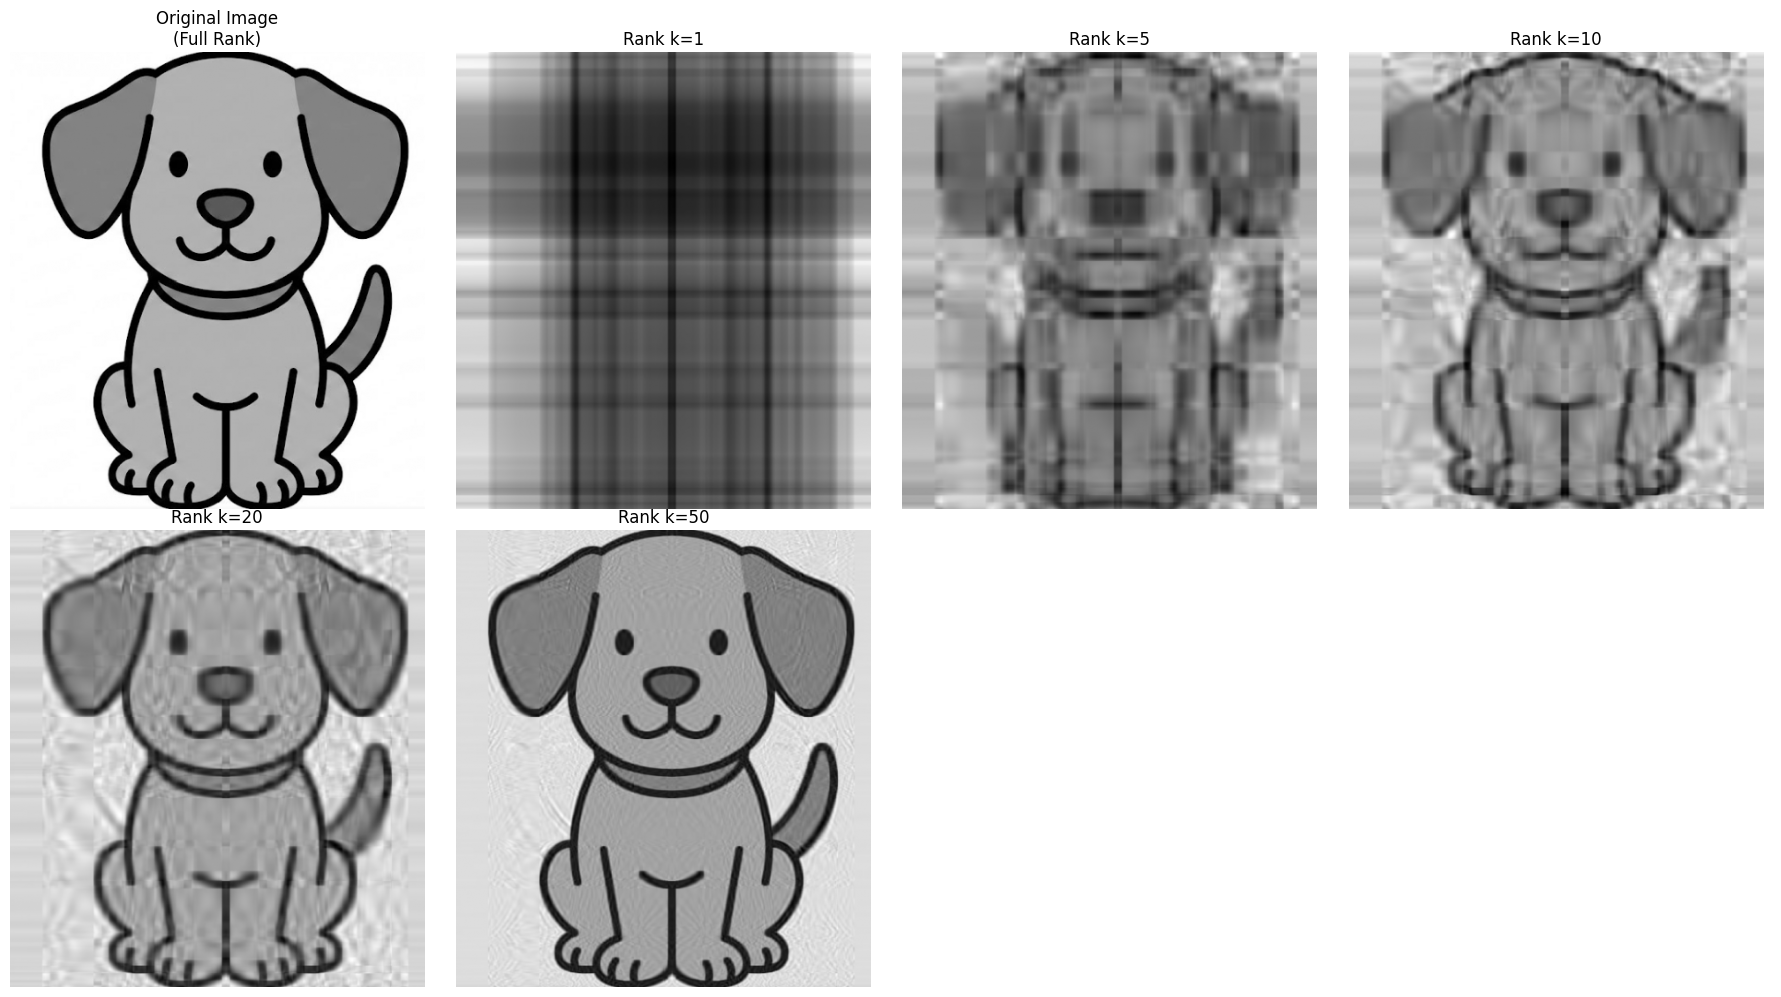

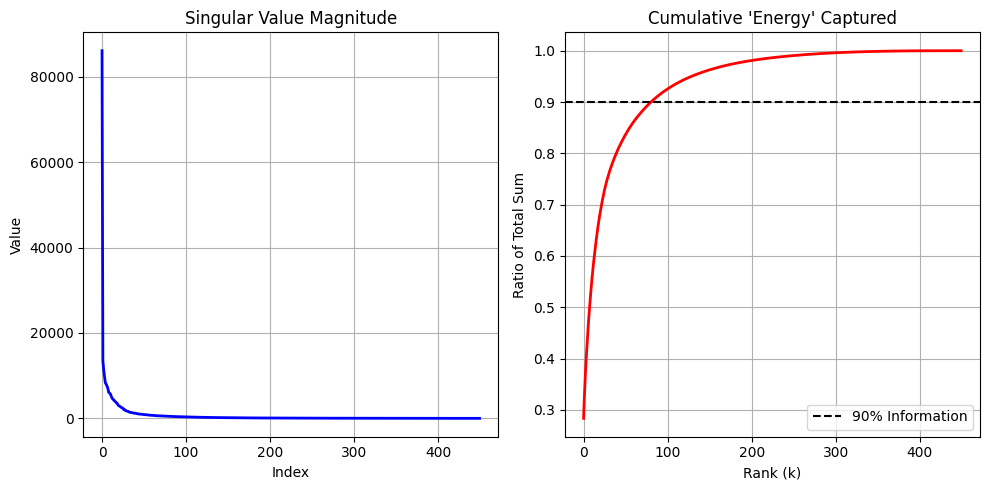

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

def analyze_image_svd(image_path, ranks=[1, 5, 10, 20, 50]):
    # 1. Load the image and convert to grayscale (L mode).
    img = Image.open(image_path).convert('L')
    img_matrix = np.array(img)

    # 2. Perform SVD.
    U, s, Vh = np.linalg.svd(img_matrix, full_matrices=False)
    spectrum_energy = s**2

    # 3. Setup visualization grid.
    n_ranks = len(ranks)
    fig, axes = plt.subplots(2, (n_ranks + 1) // 2 + 1, figsize=(18, 10))
    axes = axes.flatten()

    # Plot original image.
    axes[0].imshow(img_matrix, cmap='gray')
    axes[0].set_title("Original Image\n(Full Rank)")
    axes[0].set_xlabel(f"{img_matrix.nbytes:,} bytes")
    axes[0].axis('off')

    # 4. Reconstruct and plot truncated versions.
    for i, k in enumerate(ranks):
        # Truncation: keep only top-k singular values.
        Uk = U[:, :k]
        sk = s[:k]
        Vhk = Vh[:k, :]

        # Reconstruct: U * diag(s) * Vh.
        reconstructed = Uk @ np.diag(sk) @ Vhk
        compressed_bytes = Uk.nbytes + sk.nbytes + Vhk.nbytes

        # Display.
        ax_idx = i + 1
        axes[ax_idx].imshow(reconstructed, cmap='gray')
        axes[ax_idx].set_title(f"Rank k={k}")
        axes[ax_idx].set_xlabel(f"{compressed_bytes:,} bytes")
        axes[ax_idx].axis('off')

    # Hide any unused subplots.
    for j in range(len(ranks) + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()

    # 5. Plot singular values (the spectrum).
    plt.figure(figsize=(10, 5))

    # Plot magnitude.
    plt.subplot(1, 2, 1)
    plt.plot(s, color='blue', lw=2)
    plt.title("Singular Value Magnitude")
    plt.xlabel("Index")
    plt.ylabel("Value")
    plt.grid(True)

    # Plot cumulative energy (information captured).
    plt.subplot(1, 2, 2)
    cumulative_energy = np.cumsum(spectrum_energy) / np.sum(spectrum_energy)
    plt.plot(cumulative_energy, color='red', lw=2)
    plt.axhline(y=0.9, color='k', linestyle='--', label='90% Information')
    plt.title("Cumulative Energy Captured")
    plt.xlabel("Rank (k)")
    plt.ylabel("Ratio of Total Energy")
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()


analyze_image_svd('../images/dog.png')


The same principle that applies to image compression can extend to MPS construction of our quantum state.  If we can leverage SVD cleverly, we can build a quantum state that decently captures the full wavefunction without storing the entire SV in memory! We can then use this state just like a TN simulator to compute observables or sample from. 


The expression for an MPS is shown in the figure below.  For a given $A$, the $i$ superscript is the physical dimension and would be set to 0 or 1 depending on the bitstring we want to sample. The $\alpha$'s are the bond dimensions between the matrices and are the part we truncate when performing the SVD.  

The steps are as follows to convert a state vector $\psi$ into an MPS state.  Note, that in practice, this would be done iteratively as each gate is applied in a circuit.  Again, starting from the full state vector defeats the purpose of building a compact state we can store. However, to understand the process, it is pedagogically clearer to see how a full state is decomposed into an MPS.

We start by reshaping the state into a flattened $m \times n$ matrix where $m$ is the current bond dimension coming from the previous tensor times 2 to include the physical dimension of the current tensor. for the first tensor, $A_1$ we assume a dummy incoming bond dimension of 1.  The $n$ dimension is the rest of the wave function or $2^N/2$. 


Next, SVD is performed on this matrix. We can then examine the singular values of S and truncate any small ones larger than our choice of maximum bond dimension $\chi$. (We also truncate $U$ and $V$ accordingly.  In this first step, there will only be 2 singular values as we are performing SVD on a $2 \times 2^N/2$ matrix, so there is probably nothing to truncate yet. 

$U$ is then saved as $A_1$ and we proceed to the next location $A_2$.  Repeating the process, we now reshape $psi$ into a matrix of size $(2*2) \times 2^N/4$ as we now have an incoming bond dimension of 2 from the previous tensor $A_1$. this would correspond to $\alpha_1$ in the diagram above.  Now, when we perform SVD, we get 4 singular values.  Assume we set $\chi$ at 2, we now truncate two of the values meaning the same happens to $U$ and $V$. 

The tensor $A_2$ now becomes this $U$ with $\alpha_2$ equal to 2 rather than 4 if we did not truncate. This is where we have now trimmed data systematically, but conserved the number of parameters we store. 

Moving on to $A_3$ we now have an incoming dimension of $\alpha_2 =2$ (rather than 4 without truncation) which is used as the process continues until the end. The result is a set of MPS tensors which can be contracted to return the approximate full state if truncation was used. In practice, an MPS simulator begins with the MPS structure and iteratively performs these SVD's as gates are applied, avoiding any need for the entire state vector. 

Often, the MPS diagram will be depicted as in the figure below where the thickness of the horizontal connections correspond to the bond dimension. 

<img src="../images/bond_dim.png"  title="Landscape Image" width="300">


<div style="background-color: #f9fff0; border-left: 6px solid #76b900; padding: 15px; border-radius: 4px; box-shadow: 0px 2px 4px rgba(0,0,0,0.1);">
    <h3 style="color: #76b900; margin-top: 0; margin-bottom: 10px;">Exercise 6:</h3>
    <p style="font-size: 16px; color: #333;">
Fix the code below to prepare an MPS state from an initial state vector and a $\chi$ value. Also complete the function that contracts the tensors to reconstruct the state. Analyze the impact of increasing the bond dimension on a 10 qubit GHZ state and a 10 qubit random state. Which one is more sensitive to truncation.  Test $\chi$ values of 8, 16, and 32. 
</div>


In [9]:
import numpy as np
from numpy import linalg as LA

def generate_random_state(N):
    """Generates a random normalized complex quantum state."""
    dim = 2**N
    psi = np.random.rand(dim) + 1j * np.random.rand(dim)
    psi /= LA.norm(psi)
    return psi

def generate_ghz_state(N):
    """Generates the GHZ state: (|00...0> + |11...1>) / sqrt(2)."""
    dim = 2**N
    psi = np.zeros(dim, dtype=complex)
    psi[0] = 1.0
    psi[-1] = 1.0
    psi /= LA.norm(psi)
    return psi

def dense_to_mps(psi, N, max_bond):
    """Decomposes dense state into MPS with truncation."""
    mps_tensors = []
    psi_matrix = psi.reshape(1, 2**N)
    
    for i in range(N - 1):
        # Reshape for SVD: (Left_Bond * 2, Remaining_Dim)
        current_dim_left = psi_matrix.shape[0]
        remaining_dim = psi_matrix.shape[1] // 2 
        psi_matrix = psi_matrix.reshape(current_dim_left * 2, remaining_dim)
        
        U, S, Vh = LA.svd(psi_matrix, full_matrices=False)
        
        # Truncate
        chi = min(max_bond, len(S))
        U = U[:, :chi]
        S = S[:chi]
        Vh = Vh[:chi, :]
        
        tensor = U.reshape(current_dim_left, 2, chi)
        mps_tensors.append(tensor)
        
        psi_matrix = np.diag(S) @ Vh

    last_tensor = psi_matrix.reshape(psi_matrix.shape[0], 2, 1)
    mps_tensors.append(last_tensor)
    return mps_tensors

def mps_to_dense(mps_tensors):
    """Contracts MPS back to dense vector."""
    psi_contracted = mps_tensors[0]
    
    for tensor in mps_tensors[1:]:
        # tensor shape: (Bond_Left, Physical, Bond_Right)
        # psi_contracted shape: (1, Accumulated_Physical, Bond_Left)
        
        # Contract the connecting bond
        psi_contracted = np.tensordot(psi_contracted, tensor, axes=[-1, 0])
        
        # Result shape is now 4D: (1, Accumulated_Phys, New_Phys, Bond_Right)
        s = psi_contracted.shape
        
        # Merge the two physical dimensions (index 1 and 2)
        new_shape = (s[0], s[1] * s[2], s[3])
        psi_contracted = psi_contracted.reshape(new_shape)
        
    return psi_contracted.flatten()

def compute_fidelity(psi_original, psi_approx):
    overlap = np.vdot(psi_original, psi_approx)
    return np.abs(overlap)**2

# --- MAIN EXECUTION ---
N = 10
bond_dimensions = [32, 16, 8]

states = {
    "Random State": generate_random_state(N),
    "GHZ State   ": generate_ghz_state(N)
}

print(f"{'State Type':<15} | {'Max Bond':<10} | {'Fidelity':<10} | {'Note'}")
print("-" * 65)

for name, psi in states.items():
    for chi in bond_dimensions:
        # 1. Compress
        mps = dense_to_mps(psi, N, max_bond=chi)
        # 2. Reconstruct
        psi_recon = mps_to_dense(mps)
        # 3. Compare
        fid = compute_fidelity(psi, psi_recon)
        
        # Add context note
        if fid > 0.999999:
            note = "Perfect Reconstruction"
        else:
            note = "Information Loss"
            
        print(f"{name:<15} | {chi:<10} | {fid:.6f}   | {note}")
    print("-" * 65)

State Type      | Max Bond   | Fidelity   | Note
-----------------------------------------------------------------
Random State    | 32         | 1.000000   | Perfect Reconstruction
Random State    | 16         | 0.941252   | Information Loss
Random State    | 8          | 0.749553   | Information Loss
-----------------------------------------------------------------
GHZ State       | 32         | 1.000000   | Perfect Reconstruction
GHZ State       | 16         | 1.000000   | Perfect Reconstruction
GHZ State       | 8          | 1.000000   | Perfect Reconstruction
-----------------------------------------------------------------


As you probably noticed from Exercise 6, the random state is far more sensitive to truncated bond dimension. The GHZ state, due to its highly structured entanglement, only requires a maximum bond dimension of 2. This demonstrates that MPS is best suited for circuits with low entanglement. Circuits with all-to-all connectivity can quickly suffer from MPS approximation, while systems like spin chains are well suited for MPS.

The key benefit of MPS simulation is that $\chi$ is tunable. It provides the flexibility to optimize the extent of approximation to match the entanglement needs of the circuit. Thus, MPS is a powerful middle ground between TN and SV simulators and is particularly useful for square-shaped circuits.

CUDA-Q allows users to run MPS simulations with the `tensornet-mps` backend, which handles the implementation details needed to execute quickly on a GPU. Users can specify the maximum bond dimension and other settings like which SVD algorithm to use. Note that just because MPS uses an approximation does not mean it is faster. In cases where SV simulation is available, it should be the first choice for performance, and MPS should be used when scaling beyond its reach.


## Pauli Propagation

Just because MPS and TN simulations can scale to larger qubit numbers, they are not necessarily fast enough for all situations. In the specific case where the goal is to calculate an expectation value of an operator, Pauli propagation can be used to obtain results much faster and at large scale.

Pauli propagation works unlike any of the other methods so far, which are all focused on building some exact or approximate representation of the state. Instead, Pauli propagation begins with the observable operator and propagates backwards through all of the gates in the circuit to determine the behavior of measuring such an operator.

A Clifford gate is a gate that maps Pauli strings to Pauli strings under conjugation. For example, $H Z H = X$, and CNOT maps a $Z$ on the target wire to $Z$ on both the control and target wires. This makes Clifford gates especially convenient for Pauli propagation.

Consider a simple two-qubit circuit where we want to measure $I_1 Z_2$ for a Bell-state circuit. First, we work from the end of the circuit and track the impact of the CNOT gate. A CNOT maps that operator to $Z_1 Z_2$. Finally, the $H$ gate acts on the operator corresponding to the first qubit and modifies the $Z$ to an $X$, resulting in a propagated Pauli operator of $X_1 Z_2$.

The expectation value (for the initial $\ket{00}$ state) $\bra{00} X_1 Z_2 \ket{00}$ is determined by summing the coefficients of the Pauli strings that only contain $I$ and $Z$ terms. In this example, there are none, so the result is 0. This makes sense because the operator $X_1 Z_2$ results in a term like $\bra{00}\ket{10} = 0$.

This first example makes it look easy. Why would we not do this all the time if it is much easier than preparing a state? The answer is that we have not yet encountered gates that cause branching. Consider measurement of $Z_1 Z_2$ in a two-qubit circuit which has a single $R_X(\pi/16)$ rotation gate on the first qubit. With Clifford gates, a single input Pauli results in a single output Pauli. Non-Clifford gates like $R_X$ take a single Pauli string to a linear combination of Pauli strings, a phenomenon called branching.

In this example, the $R_X$ gate takes $Z_1 Z_2$ to $\cos(\pi/16) Z_1 Z_2 + \sin(\pi/16) Y_1 Z_2 \approx 0.98 Z_1 Z_2 + 0.20 Y_1 Z_2$. Now, when we compute the expectation value with the initial $\ket{00}$ state, only the first term contributes so the expectation value is 0.98.

If you want to explore this more, try this widget where you can change the operators and see how it impacts the Pauli propagation of a few circuits.

<div style="background-color: #f9fff0; border-left: 6px solid #76b900; padding: 15px; border-radius: 4px; box-shadow: 0px 2px 4px rgba(0,0,0,0.1);">
    <h3 style="color: #76b900; margin-top: 0; margin-bottom: 10px;">Exercise 7:</h3>
    <p style="font-size: 16px; color: #333;">
Using CUDA-Q, confirm that the worked-out examples above, and some example selections from the widget, produce the correct expectation values.
</div>


In [10]:
import numpy as np

@cudaq.kernel
def bell_state():
    reg = cudaq.qvector(2)

    h(reg[0])
    x.ctrl(reg[0], reg[1])

@cudaq.kernel
def rx_rotation():
    reg = cudaq.qvector(2)

    rx(np.pi/16, reg[0])


O1 = spin.i(0)*spin.z(1)
O2 = spin.z(0)*spin.z(1)



print(cudaq.observe(bell_state, O1).expectation())
print(cudaq.observe(rx_rotation, O2).expectation())

0.0
0.9807852804032305


The primary limitation of Pauli propagation is branching, as it exponentially grows the number of terms that need to be tracked as the number of non-Clifford gates grows. This is often handled by truncation. Consider some string like $0.58 P_1 + 0.79 P_2 + 0.01 P_3 + 0.20 P_4$. One might perform Pauli propagation with some preset threshold like 0.02 and then drop terms that have coefficients below this, in this case $P_3$. The remaining terms would then be renormalized and tracked without the need to follow any of the results that would come from the $P_3$ branch. Note that it may be tempting to drop terms that currently do not contribute to the expectation value, but the remaining gates may transform these terms into significant contributions, so there is no way to know a priori which terms have no impact.

Truncation based on a minimum threshold makes Pauli propagation scalable, but it also introduces error with every truncation step, and those errors can accumulate and corrupt results. Thus, Pauli propagation is a fantastic tool (without truncation) for large circuits with relatively few non-Clifford gates. It is also great (with truncation) for evaluating cheap expectation values for large circuits, but great care must be taken to ensure truncation does not have too great an impact on the end result.

Another important limitation is that Pauli propagation tracks observables rather than amplitudes, so it does not directly produce bitstring measurement samples from the final circuit. For example, it can help optimize the QAOA cost Hamiltonian, but if you ultimately want a candidate max-cut bitstring from the optimized circuit, you would still turn to another simulator such as TN or MPS to sample that circuit.

<div style="background-color: #f9fff0; border-left: 6px solid #76b900; padding: 15px; border-radius: 4px; box-shadow: 0px 2px 4px rgba(0,0,0,0.1);">
    <h3 style="color: #76b900; margin-top: 0; margin-bottom: 10px;">Exercise 8:</h3>
    <p style="font-size: 16px; color: #333;">

Options here: 1. Skip this exercise for now. 2. Ideally, wait for CUDA-Q to expose PP directly and then compare MPS and PP on the same expectation-value task. 3. As an advanced extension, use cuPP and cuTensorNet directly in a standalone script.
</div>


## Stabilizer Simulation

The final simulation technique we discuss here is stabilizer simulation. Stabilizer simulation works similarly to Pauli propagation, but only for Clifford circuits. Stabilizers (covered in depth in QEC 101 Lab 2) are special operators that stabilize a state. That is, if $\ket{\psi}$ lies in the stabilized subspace, a stabilizer $S$ acts on it such that $S\ket{\psi} = \ket{\psi}$. In that case, the stabilizer returns the original state.

Each Clifford circuit can be associated with a stabilizer group which essentially describes the constraints required to build that circuit. A simulation usually begins with the stabilizer $Z_1 Z_2 \dots Z_n$, which stabilizes $\ket{0 \dots 0}$. Then, just like for Pauli propagation, this stabilizer is tracked as all of the gates in the circuit are applied. Because none of them are non-Clifford, branching does not occur so tens of thousands of qubits can be simulated.

Stabilizer simulation is not suited for general algorithm testing because any useful quantum algorithm will require non-Clifford gates; otherwise it is efficiently classically simulable per the Gottesman-Knill theorem. However, it is a powerful technique for QEC researchers.

For example, if you developed a new QEC code, you may want to determine its threshold, the physical error rate for which adding more physical qubits lowers the logical error rate rather than makes things worse. You could run large-scale noisy stabilizer simulations with Clifford circuits and Pauli noise models and numerically evaluate the threshold. Similarly, you can use stabilizer simulation to test protocols for techniques like magic state distillation.

Stabilizer simulators are also workhorses for generating synthetic data that can be used for testing new decoders and training QEC-related AI models.

Extracting expectation values and samples from a stabilizer simulation is somewhat involved and beyond the scope of this lesson. Tools like cuStabilizer (GPU-accelerated stabilizer simulation) and CUDA-Q's STIM backend handle this for you.

For a detailed example where stabilizer simulation is useful for QEC, check out the [QEC 101 notebook on topological codes](https://github.com/NVIDIA/cuda-q-academic/blob/main/qec101/06_QEC_Topological_Codes.ipynb), where a stabilizer simulator is used to prepare an example of the distance-3 surface code.

<div style="background-color: #f9fff0; border-left: 6px solid #76b900; padding: 15px; border-radius: 4px; box-shadow: 0px 2px 4px rgba(0,0,0,0.1);">
    <h3 style="color: #76b900; margin-top: 0; margin-bottom: 10px;">Exercise 9:</h3>
    <p style="font-size: 16px; color: #333;">

The CUDA-Q STIM backend is fantastic for simulating QEC experiments. Try running the code below which performs a memory experiment with the surface code. If you are not familiar with QEC or memory experiments, check out the CUDA-Q Academic QEC 101 course lessons 1 and 2. If you are familiar with QEC, study the workflow to understand how the STIM backend is used here.

Each sample produces a list of measurements of the ancilla qubits (stored in `syndrome`) and the data qubits (stored as `data`). Add a print statement to see how many qubits are simulated for surface codes of distance 3, 5, 7, and 9.

</div>


In [11]:
import numpy as np
import cudaq
import cudaq_qec as qec

# Get a QEC code
cudaq.set_target("stim")
distance = 3
surface_code = qec.get_code("surface_code", distance=distance)

# Get the Z observables.
Lz = surface_code.get_observables_z()
print(f"Lz:\n{Lz}")

nShots = 1000
nRounds = distance

# Uncomment for repeatability
# cudaq.set_random_seed(13)

# error probability
p = 0.001
noise = cudaq.NoiseModel()
noise.add_all_qubit_channel("x", cudaq.Depolarization2(p), 1)

# prepare logical |0> state, tells the sampler to do z-basis experiment
statePrep = qec.operation.prep0
# our expected measurement in this state is 0
expected_value = 0

# Get the detector error model for this circuit.
dem = qec.z_dem_from_memory_circuit(surface_code, statePrep, nRounds, noise)

# For large runs, set verbose to False to suppress output
verbose = nShots <= 10

# Sample the surface code memory circuit with noise on each cx gate
syndromes, data = qec.sample_memory_circuit(surface_code, statePrep, nShots,
                                            nRounds, noise)
#TODO
print("Number of Ancilla Qubits", len(syndromes[0]))
print("Number of Data Qubits", len(data[0]))

if verbose:
    print("From sample function:\n")
    print("syndromes:\n", syndromes)
    print("data:\n", data)

# Get a decoder
decoder = qec.get_decoder("single_error_lut", dem.detector_error_matrix)
nLogicalErrors = 0

# Logical Mz each shot (use Lx if preparing in X-basis)
logical_measurements = (Lz @ data.transpose()) % 2
# only one logical qubit, so do not need the second axis
logical_measurements = logical_measurements.flatten()


# Reshape and drop the X stabilizers, keeping just the Z stabilizers (since this is prep0)
syndromes = syndromes.reshape((nShots, nRounds, -1))
syndromes = syndromes[:, :, :syndromes.shape[2] // 2]
# Now flatten to two dimensions again
syndromes = syndromes.reshape((nShots, -1))

dr = decoder.decode_batch(syndromes)
error_predictions = np.array([e.result for e in dr], dtype=np.uint8)
data_predictions = (dem.observables_flips_matrix @ error_predictions.T) % 2

nLogicalErrorsWithoutDecoding = np.sum(logical_measurements)
nLogicalErrorsWithDecoding = np.sum(data_predictions ^ logical_measurements)
print(
    f'Number of logical errors without decoding (out of {nShots} shots): {nLogicalErrorsWithoutDecoding}'
)
print(
    f'Number of logical errors with decoding    (out of {nShots} shots): {nLogicalErrorsWithDecoding}'
)

Lz:
[[1 0 0 1 0 0 1 0 0]]
Number of Ancilla Qubits 8
Number of Data Qubits 9
Number of logical errors without decoding (out of 1000 shots): 18
Number of logical errors with decoding    (out of 1000 shots): 9


## Summary

Hopefully it is now clear that there are many different tools available for quantum algorithm simulation depending on the situation. You should now have an understanding of the basics of how each simulator works, what its strengths and weaknesses are, and what some common use cases are.

For most situations, you will probably still use SV, TN, and MPS simulations. The chart below gives a reasonable qualitative representation of the three regimes where each is most useful.

<img src="../images/backend_chart.png" alt="Qualitative comparison chart for SV, TN, and MPS simulation regimes" width="700">

In cases where cheap expectation values are required, Pauli propagation is a tool to consider. When you need large-circuit sampling rather than just observables, TN or MPS may still be the better choice. For specialized cases, often related to QEC, stabilizer simulation is the best choice.

Each of these simulation methods can benefit from GPU acceleration, often with implementations that are far from trivial. The NVIDIA CUDA-Q platform and underlying cuQuantum libraries make it easy to benefit from whatever sort of accelerated simulation you need. The [CUDA-Q applications page](https://nvidia.github.io/cuda-quantum/latest/using/applications.html) and the other [CUDA-Q Academic learning paths](https://github.com/NVIDIA/cuda-q-academic) have many examples demonstrating cases where these simulation tools can be used for a diverse range of applications.
